# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

## Answer

Preattentive attributes are visual properties the human visual system processes before conscious attention — within approximately 250 milliseconds of viewing. Using them strategically directs the viewer's eye to the last three months *before* they read the rest of the chart. Here are several concrete approaches:

---

### 1. Color (most powerful option)
Plot the first nine months in light grey and the last three months in a saturated, distinct color (e.g., deep blue or orange). Color is the strongest preattentive attribute for isolating a region in a line chart. The eye will snap to the colored segment immediately, regardless of where it falls on the page.

> *Implementation:* Split each series into two line segments at the 9-month mark. Plot the first segment with `color='#CCCCCC'` and the last segment with `color='#1F5FA6'`. Add a direct label ("Last 3 months") next to the colored portion.

---

### 2. Line weight (intensity / thickness)
Keep the first nine months as a thin, faint line and make the last three months a thicker, bolder line. The heavier stroke weight creates a region of higher visual intensity that draws the eye.

> *Implementation:* Use `linewidth=1` for the historical portion and `linewidth=3` for the last three months. Combine with a slightly higher `alpha` on the recent segment for added contrast.

---

### 3. Shaded region (enclosure)
Add a light rectangular shaded background behind the last three months — a technique called *enclosure*. The bounded region pops visually from the unshaded background, signaling "this area is different; examine it first."

> *Implementation:* Use `ax.axvspan(start_of_month_10, end_of_month_12, alpha=0.12, color='steelblue')`. Add a small label at the top of the shaded band ("Oct – Dec 2023").

---

### 4. Annotations / text callouts (added marks)
Place a text annotation or arrow directly on the last data point or over the last three months. Even a small label introduces a new visual object that the eye treats as a point of interest and prioritizes.

> *Implementation:* Use `ax.annotate("Final quarter", xy=(last_date, last_value), xytext=(...), arrowprops=dict(...))`. The arrow tip and bold text act as a pointer before the viewer has consciously processed the chart.

---

### 5. Marker size (size attribute)
Add larger, filled data-point markers exclusively at the last three monthly values. In a line graph where most points have no markers (or small ones), the sudden appearance of larger dots in the final three positions creates an immediate contrast in size that preattentively directs attention.

> *Implementation:* Plot the full line without markers, then overlay a scatter of the last three points with `s=80`, `zorder=5`, and a matching bold color.

---

### Best combined approach

The most effective solution combines **color + shading**: grey out the first nine months, apply a bold highlight color to the last three, and add a light shaded background over that region. This uses two independent preattentive channels simultaneously, making the signal nearly impossible to miss before the viewer reads a single label or axis tick.


In [10]:
import numpy as np
import seaborn as sns
import pandas as pd

/var/folders/qk/nvp_lxh55cq1609wns9m750cy_qfs_/T/ipykernel_12168/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

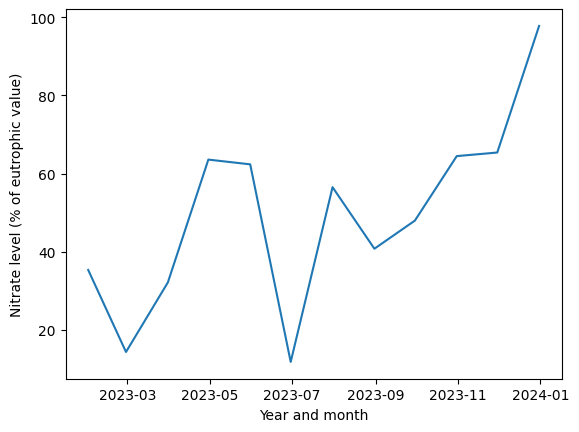

In [7]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/qk/nvp_lxh55cq1609wns9m750cy_qfs_/T/ipykernel_12168/1012779568.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

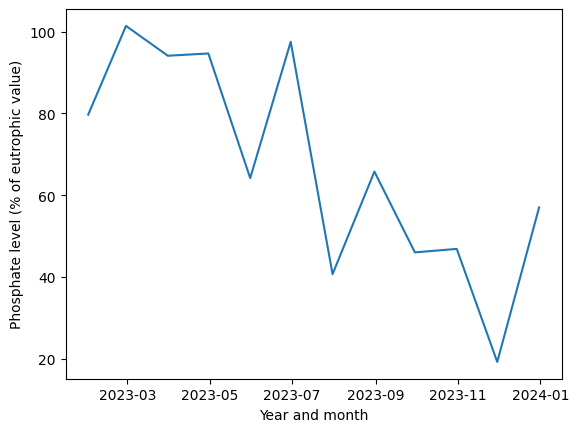

In [8]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

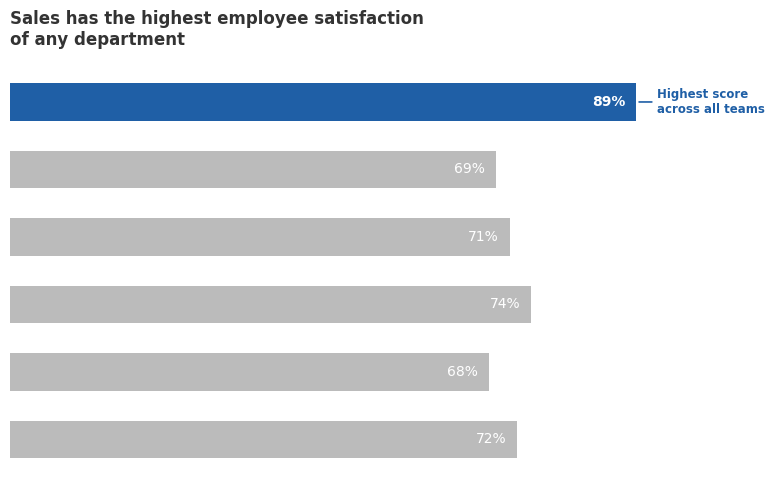

In [9]:
# ── Storytelling With Data – Chapter 4 (pp. 99-119) ─────────────────────────
# Reproduces the "highlight one, grey the rest" horizontal bar chart style.
# SWD design principles applied (Think Like a Designer):
#   • Single purposeful color draws the eye to the story bar
#   • All other bars in neutral grey — present but not competing
#   • No gridlines, no tick marks, no border box
#   • Data values labeled directly on each bar (no axis needed)
#   • Left-aligned title that states the conclusion, not just the topic
#   • Subtle annotation to reinforce the story

import matplotlib.pyplot as plt
import numpy as np

# ── Data (approximate — look & feel is what matters) ─────────────────────────
departments   = ["Finance", "Operations", "HR", "Marketing", "Engineering", "Sales"]
satisfaction  = [72, 68, 74, 71, 69, 89]   # % employee satisfaction score
highlight_dept = "Sales"                    # the story: Sales is the standout

GREY  = "#BBBBBB"
BLUE  = "#1F5FA6"
WHITE = "white"

colors = [BLUE if d == highlight_dept else GREY for d in departments]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# Horizontal bars
bars = ax.barh(departments, satisfaction, color=colors,
               height=0.55, edgecolor="none")

# Direct value labels on each bar
for bar, val, dept in zip(bars, satisfaction, departments):
    is_hi = (dept == highlight_dept)
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height() / 2,
            f"{val}%",
            ha="right", va="center",
            fontsize=10,
            color=WHITE,
            fontweight="bold" if is_hi else "normal")

# Annotation pointing to the highlighted bar
hi_idx = departments.index(highlight_dept)
ax.annotate("Highest score\nacross all teams",
            xy=(satisfaction[hi_idx], hi_idx),
            xytext=(satisfaction[hi_idx] + 3, hi_idx),
            fontsize=8.5, color=BLUE, fontweight="bold",
            va="center",
            arrowprops=dict(arrowstyle="-", color=BLUE, lw=1.2))

# Left-aligned bold title that tells the story (SWD Chapter 4 principle)
ax.set_title("Sales has the highest employee satisfaction\nof any department",
             fontsize=12, fontweight="bold", color="#333333",
             loc="left", pad=12)

# Set x-axis range but hide everything chrome-related
ax.set_xlim(0, 105)
ax.set_ylim(-0.6, len(departments) - 0.4)

# Remove all chart junk
ax.axis("off")

plt.tight_layout()
plt.show()
